# aule — Climate metrics

This notebook covers `aule.metrics.climate`: metrics that operate along the **time axis**, designed for climate model validation use cases (seasonal cycles, extremes, trends, temporal persistence). These metrics require a meaningful time dimension, so we always pass `data_format='hwct'` to indicate the array shape is `(H, W, C, T)`.

In [ ]:
!pip install aule

## Setup

We simulate a 100-time-step field with a seasonal-like oscillation plus a slow warming trend, then add noise for the "prediction".

In [1]:
import numpy as np

np.random.seed(1)

T = 100
t = np.arange(T)
seasonal_signal = np.sin(2 * np.pi * t / 20)        # fast oscillation, like a seasonal cycle
trend_signal    = 0.01 * t                          # slow linear warming trend

base = (seasonal_signal + trend_signal).reshape(1, 1, 1, T)
gt   = np.tile(base, (32, 32, 1, 1)) + np.random.normal(0, 0.05, (32, 32, 1, T))
pred = gt + np.random.normal(0, 0.1, gt.shape)

print('gt shape:', gt.shape)  # (H, W, C, T)

gt shape: (32, 32, 1, 100)


## Seasonal error

`seasonal_error` compares the spatial-mean time series of ground truth vs prediction (i.e. how well the model captures the temporal evolution, ignoring spatial detail).

In [2]:
from aule.metrics import seasonal_error

score = seasonal_error(gt, pred, data_format='hwct')
print('Seasonal error (MSE of spatial-mean series):', score)

Seasonal error (MSE of spatial-mean series): 1.0472799977486848e-05


## Percentile error

Useful for checking whether a model captures extremes well, even if average behavior looks fine. For example, P95 captures heatwave-like extremes; P5 captures cold extremes.

In [3]:
from aule.metrics import percentile_error

print('P95 error:', percentile_error(gt, pred, percentile=95.0))
print('P5 error: ', percentile_error(gt, pred, percentile=5.0))

P95 error: 0.010424143756250226
P5 error:  0.009620995202253346


## Pixel-wise temporal correlation

`pixelwise_temporal_correlation` computes, at every pixel, the Pearson correlation across time between ground truth and prediction — giving a correlation *map* rather than a single number. Useful to spot regions where temporal dynamics are poorly captured.

In [4]:
from aule.metrics import pixelwise_temporal_correlation

r_map = pixelwise_temporal_correlation(gt, pred, data_format='hwct')
print('r_map shape:', r_map.shape)  # (H, W, C)
print('Mean correlation:', r_map.mean())
print('Min correlation: ', r_map.min())

r_map shape: (32, 32, 1)
Mean correlation: 0.9908165251191837
Min correlation:  0.9866698175893492


## Trend error

`trend_error` fits a linear trend (least squares) to the spatial-mean time series of both ground truth and prediction, then compares the slopes. This isolates whether the model gets the *long-term trend* right, independent of short-term variability.

In [5]:
from aule.metrics import trend_error

score = trend_error(gt, pred, data_format='hwct')
print('Trend slope error:', score)

Trend slope error: 5.246034987207125e-06


## Extreme event duration error

`extreme_event_duration_error` measures the mean duration of "events" (consecutive time steps above/below a threshold, e.g. heatwaves or cold spells) and compares ground truth vs prediction.

In [6]:
from aule.metrics import extreme_event_duration_error

threshold = 0.8
score = extreme_event_duration_error(gt, pred, threshold=threshold, above=True, data_format='hwct')
print(f'Mean event-duration error (threshold={threshold}):', score)

Mean event-duration error (threshold=0.8): 0.0


## Autocorrelation error

`autocorrelation_error` compares the temporal autocorrelation function (ACF) up to a maximum lag — relevant for checking whether a model preserves temporal persistence (e.g. drought persistence, slow climate modes like ENSO).

In [7]:
from aule.metrics import autocorrelation_error

score = autocorrelation_error(gt, pred, max_lag=10, data_format='hwct')
print('Mean ACF error (lags 1-10):', score)

Mean ACF error (lags 1-10): 0.00014933014327054295


## Wet-day frequency error

Models often get total precipitation right on average while badly misrepresenting how many days actually have rain (the classic "drizzle bias", where a model rains a little every day instead of a lot on a few days). `wet_day_frequency_error` isolates this by comparing how often a threshold is exceeded, not the magnitude of exceedance.

In [8]:
# simulate precipitation-like data: exponential distribution, mostly small values with occasional large ones
precip_gt   = np.random.exponential(1.0, (32, 32, 1, 60))
precip_pred = precip_gt * 0.85  # systematically drier prediction

from aule.metrics import wet_day_frequency_error

score = wet_day_frequency_error(precip_gt, precip_pred, threshold=1.0, data_format='hwct')
print('Wet-day frequency error:', score)

Wet-day frequency error: 0.5833333333333334


## Dry-spell error

`dry_spell_error` is a convenience wrapper around `extreme_event_duration_error` specialized for the common case of measuring how well a model reproduces the length of dry spells (consecutive time steps below a threshold) — relevant for drought monitoring.

In [9]:
from aule.metrics import dry_spell_error

score = dry_spell_error(precip_gt, precip_pred, threshold=1.0, data_format='hwct')
print('Mean dry-spell duration error:', score)

Mean dry-spell duration error: 58.4375


## Anomaly Correlation Coefficient (ACC)

A model that simply reproduces the climatological seasonal cycle can score deceptively well on raw correlation. ACC strips out the climatology first and correlates only the *anomalies* (departures from normal), which is the standard skill metric in numerical weather prediction and seasonal forecasting.

In [10]:
from aule.metrics import anomaly_correlation_coefficient

# a simple climatology: the long-term mean at each pixel
climatology = gt.mean(axis=-1, keepdims=True)

acc = anomaly_correlation_coefficient(gt, pred, climatology, data_format='hwct')
print('Anomaly Correlation Coefficient:', acc)

Anomaly Correlation Coefficient: 0.9906264582060105


## Visualizing the spatial-mean time series

A quick plot helps interpret the metrics above: we can see the seasonal cycle, the slow trend, and how closely the (noisy) prediction follows the ground truth.

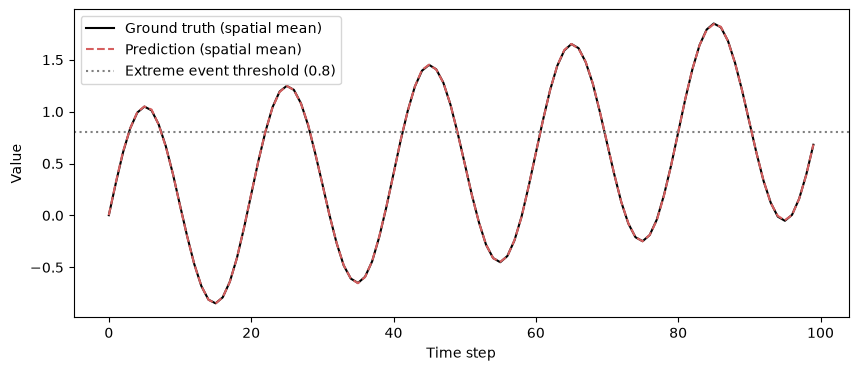

In [11]:
import matplotlib.pyplot as plt

gt_mean = gt.mean(axis=(0, 1, 2))
pred_mean = pred.mean(axis=(0, 1, 2))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, gt_mean, label='Ground truth (spatial mean)', color='black')
ax.plot(t, pred_mean, label='Prediction (spatial mean)', color='#D65F5F', ls='--')
ax.axhline(threshold, color='gray', ls=':', label=f'Extreme event threshold ({threshold})')
ax.set_xlabel('Time step')
ax.set_ylabel('Value')
ax.legend()
plt.show()